In [ ]:
import numpy as np

# Define dimensions
num_channels = 4  # Channels: 1, 2, 3, 4 (indices 0-3)
value_range = (0, 10)  # Values: 0 to 10 (11 values, indices 0-10)
z_range = (0, 11)  # z: 0 to 11 (12 values, indices 0-11)
y_range = (0, 86)  # y: 0 to 86 (87 values, indices 0-86)
x_range = (0, 171)  # x: 0 to 171 (172 values, indices 0-171)

# Calculate array dimensions
num_values = value_range[1] - value_range[0] + 1  # 11 values (0-10)
z_dim = z_range[1] - z_range[0] + 1  # 12 values (0-11)
y_dim = y_range[1] - y_range[0] + 1  # 87 values (0-86)
x_dim = x_range[1] - x_range[0] + 1  # 172 values (0-171)

# Create 5D array initialized with zeros
# Shape: (channel, value, z, y, x)
data = np.zeros((num_channels, num_values, z_dim, y_dim, x_dim), dtype=np.int8)

# Generate random values for each (z, y, x) position
for i in range(0, 3):
    for z in range(z_dim):
        # Channel 0: x ranges 38+40*i to 43+40*i, for all y
        for y in range(y_dim):
            x_start = max(0, 38+20*i)
            x_end = min(x_dim, 43+20*i)
            for x in range(x_start, x_end):
                random_value = np.random.randint(6, 11)
                data[0, random_value, z, y, x] = 1
        # Channel 1: y ranges 18+20*i to 23+20*i, for all x
        y_start = max(0, 18+20*i)
        y_end = min(y_dim, 23+20*i)
        for y in range(y_start, y_end):
            for x in range(x_dim):
                random_value = np.random.randint(6, 11)
                data[1, random_value, z, y, x] = 1
        # Channel 2: 1 diagonal lines with slope 1 (y = x + c)
        strip_width = 3  # Narrower width for diagonal strips
        c_values = [-60, 0]  # 3 lines: y=x-60, y=x, y=x+60
        for c in c_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y - x - c) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[2, random_value, z, y, x] = 1
        # Channel 3: 1 diagonal lines with slope -1 (y = -x + d)
        strip_width = 3  # Narrower width for diagonal strips
        d_values = [60, 120]  # 3 lines: y=-x+60, y=-x+120, y=-x+180
        for d in d_values:
            for y in range(y_dim):
                for x in range(x_dim):
                    if abs(y + x - d) <= strip_width:
                        random_value = np.random.randint(6, 11)
                        data[3, random_value, z, y, x] = 1

print(f"Created 5D data array with shape: {data.shape}")
print(f"Dimensions breakdown:")
print(f"  - Channels: {num_channels} (1, 2, 3, 4)")
print(f"  - Values: {num_values} (0 to {value_range[1]})")
print(f"  - Z: {z_dim} (0 to {z_range[1]})")
print(f"  - Y: {y_dim} (0 to {y_range[1]})")
print(f"  - X: {x_dim} (0 to {x_range[1]})")
print(f"\nData type: {data.dtype}")
print(f"Total elements: {data.size:,}")
print(f"Memory size: {data.nbytes / 1024 / 1024:.2f} MB")

# Save the data
np.save('groundtruth.npy', data)
print(f"\n✓ 5D data saved to: groundtruth.npy")


Created 5D data array with shape: (4, 11, 12, 87, 172)
Dimensions breakdown:
  - Channels: 4 (1, 2, 3, 4)
  - Values: 11 (0 to 10)
  - Z: 12 (0 to 11)
  - Y: 87 (0 to 86)
  - X: 172 (0 to 171)

Data type: int8
Total elements: 7,900,992
Memory size: 7.53 MB

✓ 5D data saved to: groundtruth.npy


C:\Users\hosse\AppData\Local\Temp\ipykernel_21548\3125284008.py:12: RuntimeWarning: invalid value encountered in divide
  avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)


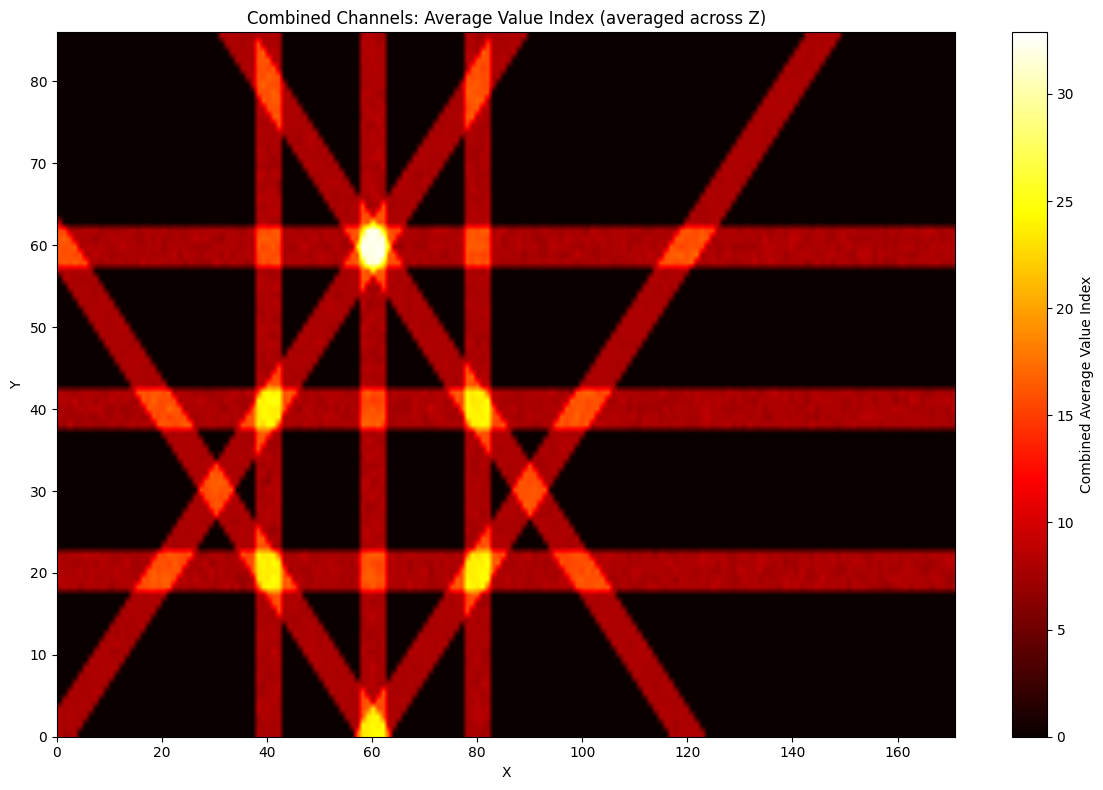


✓ Combined channels visualization
  Image shape: (87, 172)
  Value range: [0.00, 32.88]


In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Load data
data = np.load('groundtruth.npy')
combined_image = np.zeros((y_dim, x_dim), dtype=np.float32)
for channel in range(4):
    channel_data = data[channel]  # Shape: (11, 12, 87, 172)
    value_indices = np.arange(11).reshape(-1, 1, 1, 1)  # Shape: (11, 1, 1, 1)
    weighted_sum = np.sum(value_indices * channel_data, axis=0)  # Shape: (12, 87, 172)
    total_sum = np.sum(channel_data, axis=0)  # Shape: (12, 87, 172)
    avg_value_index = np.where(total_sum > 0, weighted_sum / total_sum, 0)  # Shape: (12, 87, 172)
    avg_z = np.mean(avg_value_index, axis=0)  # Shape: (87, 172)
    combined_image += avg_z
# Plot combined image
plt.figure(figsize=(12, 8))
plt.imshow(combined_image, origin='lower', extent=[0, x_dim-1, 0, y_dim-1], 
           aspect='auto', interpolation='bilinear', cmap='hot')
plt.colorbar(label='Combined Average Value Index')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Combined Channels: Average Value Index (averaged across Z)')
plt.xlim(0, x_dim-1)
plt.ylim(0, y_dim-1)
plt.tight_layout()
plt.show()

print(f"\n✓ Combined channels visualization")
print(f"  Image shape: {combined_image.shape}")
print(f"  Value range: [{combined_image.min():.2f}, {combined_image.max():.2f}]")


In [49]:
import numpy as np

# Load groundtruth data
data = np.load('groundtruth.npy')
print(f"Data shape: {data.shape}")

# Extract data for z=1 (z index 1)
z_index = 5
z_data = data[:, :, z_index, :, :]  # Shape: (4, 11, 87, 172) - all channels, all values, z=1, all y, all x

# For each (x, y) coordinate, check which channels have non-zero values
# Sum across value dimension to check if channel has any non-zero value
channel_sums = np.sum(z_data, axis=1)  # Shape: (4, 87, 172) - sum across value dimension
channel_has_data = (channel_sums > 0).astype(int)  # Shape: (4, 87, 172) - 1 if channel has data, 0 otherwise

# Count number of channels with non-zero values for each (x, y) coordinate
num_channels_per_coord = np.sum(channel_has_data, axis=0)  # Shape: (87, 172)

# Count how many coordinates have 1, 2, 3, or 4 channels
count_1_channel = np.sum(num_channels_per_coord == 1)
count_2_channels = np.sum(num_channels_per_coord == 2)
count_3_channels = np.sum(num_channels_per_coord == 3)
count_4_channels = np.sum(num_channels_per_coord == 4)

# Find coordinates with 4 channels
y_indices, x_indices = np.where(num_channels_per_coord == 4)
coordinates_4_channels = list(zip(x_indices, y_indices))

# Print results
print(f"\nAnalysis for z={z_index}:")
print(f"=" * 50)
print(f"Coordinates with 1 channel:  {count_1_channel:,}")
print(f"Coordinates with 2 channels: {count_2_channels:,}")
print(f"Coordinates with 3 channels: {count_3_channels:,}")
print(f"Coordinates with 4 channels: {count_4_channels:,}")
print(f"=" * 50)
print(f"Total coordinates analyzed: {num_channels_per_coord.size:,}")
print(f"  (Y dimension: {y_dim}, X dimension: {x_dim})")

# Print coordinates with 4 channels
if count_4_channels > 0:
    print(f"\nCoordinates with 4 channels:")
    for x, y in coordinates_4_channels:
        print(f"  x,y: {x},{y}")
else:
    print(f"\nNo coordinates found with 4 channels.")


Data shape: (4, 11, 12, 87, 172)

Analysis for z=5:
Coordinates with 1 channel:  4,561
Coordinates with 2 channels: 573
Coordinates with 3 channels: 114
Coordinates with 4 channels: 21
Total coordinates analyzed: 14,964
  (Y dimension: 87, X dimension: 172)

Coordinates with 4 channels:
  x,y: 59,58
  x,y: 60,58
  x,y: 61,58
  x,y: 58,59
  x,y: 59,59
  x,y: 60,59
  x,y: 61,59
  x,y: 62,59
  x,y: 58,60
  x,y: 59,60
  x,y: 60,60
  x,y: 61,60
  x,y: 62,60
  x,y: 58,61
  x,y: 59,61
  x,y: 60,61
  x,y: 61,61
  x,y: 62,61
  x,y: 59,62
  x,y: 60,62
  x,y: 61,62


# creating graph from node and edge list

In [50]:
import numpy as np
from torch_geometric.data import Data
import torch
import os
import time

# Function to calculate 3D Euclidean distance
def calculate_distance(x1, y1, z1, x2, y2, z2):
    """Calculate 3D Euclidean distance between two points"""
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2 + (z2 - z1)**2)

# Load groundtruth data
print("Loading groundtruth data...")
data = np.load('groundtruth.npy')
print(f"✓ Data loaded with shape: {data.shape}")

# Parameters
z_fixed = 5  # Fixed z coordinate (changed from 5 to 1 to match cell 19 analysis)
max_radius = 10  # Maximum radius for graph edges
step_size = 10  # Step size for graph centers

# Get dimensions
num_channels, num_values, z_dim, y_dim, x_dim = data.shape
print(f"Dimensions: channels={num_channels}, values={num_values}, z={z_dim}, y={y_dim}, x={x_dim}")

# Extract data for z=1 only
z_idx = z_fixed
print(f"\nExtracting data for z={z_fixed} (index {z_idx})...")

# Pre-compute intensity matrix for z=1
print("Pre-computing intensity matrix for z=1...")
start_time = time.time()
intensity_matrix = np.zeros((y_dim, x_dim, num_channels), dtype=np.float32)
channel_mask = np.zeros((y_dim, x_dim, num_channels), dtype=bool)

for channel in range(num_channels):
    channel_data = data[channel, :, z_idx, :, :]  # Shape: (num_values, y_dim, x_dim)
    # Find value indices where channel_data[value_idx, y, x] = 1
    value_indices = np.argmax(channel_data, axis=0)  # Shape: (y_dim, x_dim)
    # Check if any value is set
    mask = channel_data.sum(axis=0) > 0  # Shape: (y_dim, x_dim)
    intensity_matrix[:, :, channel] = np.where(mask, value_indices.astype(np.float32), 0.0)
    channel_mask[:, :, channel] = mask

elapsed = time.time() - start_time
print(f"✓ Intensity matrix computed in {elapsed:.2f} seconds")

# Count channels for each coordinate
print("\nCounting channels per coordinate...")
channel_counts = channel_mask.sum(axis=2)  # Shape: (y_dim, x_dim)
print(f"  Coordinates with 4 channels: {(channel_counts == 4).sum()}")
print(f"  Coordinates with 3 channels: {(channel_counts == 3).sum()}")
print(f"  Coordinates with 2 channels: {(channel_counts == 2).sum()}")
print(f"  Coordinates with 1 channel: {(channel_counts == 1).sum()}")
print(f"  Total non-zero coordinates: {(channel_counts > 0).sum()}")

# Generate graph centers with step_size=20
print(f"\nGenerating graph centers with step_size={step_size}...")
graph_centers = []
for x in range(0, x_dim, step_size):
    for y in range(0, y_dim, step_size):
        graph_centers.append((x, y, z_fixed))

print(f"Total graph centers: {len(graph_centers)}")

# Create subgraphs - one list for all graphs
print("\n" + "="*60)
print("Creating subgraphs...")
print("="*60)

all_subgraphs = []  # Single list for all subgraphs

graph_start_time = time.time()

for center_idx, (center_x, center_y, center_z) in enumerate(graph_centers):
    if center_idx % 10 == 0:
        print(f"Processing center {center_idx+1}/{len(graph_centers)}: ({center_x}, {center_y}, {center_z})")
    
    # Bounding box for optimization
    bounding_radius = max_radius
    x_min = max(0, int(center_x - bounding_radius))
    x_max = min(x_dim, int(center_x + bounding_radius) + 1)
    y_min = max(0, int(center_y - bounding_radius))
    y_max = min(y_dim, int(center_y + bounding_radius) + 1)
    
    # Find all coordinates within radius from center (all non-zero coordinates)
    nodes = []
    node_positions = []
    node_active_channels = []  # Store active channels for each node
    
    for y in range(y_min, y_max):
        for x in range(x_min, x_max):
            # Check if this coordinate has any channels
            if channel_counts[y, x] > 0:
                distance = calculate_distance(center_x, center_y, center_z, x, y, z_fixed)
                if distance <= max_radius:
                    # Get active channels for this coordinate
                    active_channels = np.where(channel_mask[y, x, :])[0].tolist()
                    # Extract intensities only for active channels
                    intensities = intensity_matrix[y, x, active_channels]  # Shape: (num_active_channels,)
                    nodes.append(intensities)
                    node_positions.append((x, y, z_fixed))
                    node_active_channels.append(active_channels)
    
    if len(nodes) == 0:
        continue
    
    # Find maximum number of channels across all nodes in this graph
    max_channels = max(len(channels) for channels in node_active_channels)
    
    # Pad node features to have same number of channels (use max_channels)
    # For nodes with fewer channels, pad with zeros
    padded_nodes = []
    for i, intensities in enumerate(nodes):
        active_ch = node_active_channels[i]
        num_ch = len(active_ch)
        if num_ch < max_channels:
            # Pad with zeros
            padded = np.zeros(max_channels, dtype=np.float32)
            padded[:num_ch] = intensities
            padded_nodes.append(padded)
        else:
            padded_nodes.append(intensities)
    
    # Convert to numpy array
    node_features = np.array(padded_nodes, dtype=np.float32)  # Shape: (num_nodes, max_channels)
    node_positions_array = np.array(node_positions, dtype=np.int32)  # Shape: (num_nodes, 3)
    num_nodes = len(nodes)
    
    # Subsample by factor 2
    subsample_factor = 1
    x_coords = node_positions_array[:, 0]
    y_coords = node_positions_array[:, 1]
    z_coords = node_positions_array[:, 2]
    
    x_min_coord = x_coords.min()
    y_min_coord = y_coords.min()
    z_min_coord = z_coords.min()
    
    mask = ((x_coords - x_min_coord) % subsample_factor == 0) & \
           ((y_coords - y_min_coord) % subsample_factor == 0) & \
           ((z_coords - z_min_coord) % subsample_factor == 0)
    
    node_features = node_features[mask]
    node_positions_array = node_positions_array[mask]
    node_active_channels = [node_active_channels[i] for i in range(len(mask)) if mask[i]]
    num_nodes = len(node_features)
    
    if num_nodes < 2:
        continue
    
    # Create edges
    node_positions_np = node_positions_array.astype(np.float32)
    
    if num_nodes < 5000:
        # Vectorized approach for small graphs
        diff = node_positions_np[:, np.newaxis, :] - node_positions_np[np.newaxis, :, :]
        distances_matrix = np.sqrt(np.sum(diff**2, axis=2))
        edge_mask = (distances_matrix <= max_radius) & (distances_matrix > 0)
        edge_i, edge_j = np.where(edge_mask)
        if len(edge_i) > 0:
            edge_weights_np = 1.0 / (1.0 + distances_matrix[edge_i, edge_j])
        else:
            continue
    else:
        # Memory-efficient approach for large graphs
        edge_i_list = []
        edge_j_list = []
        edge_weights_list = []
        for i in range(num_nodes):
            if i < num_nodes - 1:
                diff = node_positions_np[i+1:] - node_positions_np[i]
                distances = np.sqrt(np.sum(diff**2, axis=1))
                mask_edges = distances <= max_radius
                if np.any(mask_edges):
                    j_indices = np.where(mask_edges)[0] + i + 1
                    edge_i_list.extend([i] * len(j_indices))
                    edge_j_list.extend(j_indices.tolist())
                    edge_i_list.extend(j_indices.tolist())
                    edge_j_list.extend([i] * len(j_indices))
                    weights = 1.0 / (1.0 + distances[mask_edges])
                    edge_weights_list.extend(weights.tolist())
                    edge_weights_list.extend(weights.tolist())
        
        if len(edge_i_list) == 0:
            continue
        edge_i = np.array(edge_i_list)
        edge_j = np.array(edge_j_list)
        edge_weights_np = np.array(edge_weights_list)
    
    # Calculate node values (sum of intensities across all channels for each node)
    node_values = np.sum(node_features, axis=1)  # Shape: (num_nodes,)
    
    # Convert to PyTorch tensors
    edge_index = torch.tensor(np.stack([edge_i, edge_j]), dtype=torch.long)
    edge_attr = torch.tensor(edge_weights_np, dtype=torch.float32)
    x_tensor = torch.tensor(node_features, dtype=torch.float32)
    node_values_tensor = torch.tensor(node_values, dtype=torch.float32)
    
    # Create PyTorch Geometric Data object
    graph = Data(
        x=x_tensor,  # Node features: (num_nodes, max_channels)
        edge_index=edge_index,  # Edge connections: (2, num_edges)
        edge_attr=edge_attr,  # Edge weights: (num_edges,)
        center=(center_x, center_y, center_z),  # Graph center position
        center_idx=center_idx,  # Index of this graph
        node_positions=[tuple(pos) for pos in node_positions_array],  # Node positions
        node_values=node_values_tensor,  # Node values: sum of intensities (num_nodes,)
        max_channels=max_channels  # Maximum number of channels in this subgraph
    )
    
    all_subgraphs.append(graph)

elapsed = time.time() - graph_start_time
print(f"\n✓ Graph creation complete in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")

# Print statistics
print("\n" + "="*60)
print("Subgraph Statistics:")
print("="*60)

if len(all_subgraphs) > 0:
    num_nodes_list = [g.x.shape[0] for g in all_subgraphs]
    num_edges_list = [g.edge_index.shape[1] for g in all_subgraphs]
    num_channels_list = [g.x.shape[1] for g in all_subgraphs]
    
    print(f"Total subgraphs: {len(all_subgraphs)}")
    print(f"Average nodes per subgraph: {np.mean(num_nodes_list):.1f}")
    print(f"Average edges per subgraph: {np.mean(num_edges_list):.1f}")
    print(f"Average channels per subgraph: {np.mean(num_channels_list):.1f}")
    print(f"Total nodes: {sum(num_nodes_list):,}")
    print(f"Total edges: {sum(num_edges_list):,}")
    print(f"\nChannel distribution:")
    print(f"  Subgraphs with 1 channel: {sum(1 for c in num_channels_list if c == 1)}")
    print(f"  Subgraphs with 2 channels: {sum(1 for c in num_channels_list if c == 2)}")
    print(f"  Subgraphs with 3 channels: {sum(1 for c in num_channels_list if c == 3)}")
    print(f"  Subgraphs with 4 channels: {sum(1 for c in num_channels_list if c == 4)}")
else:
    print("No subgraphs created.")

# Save all subgraphs to one file
print("\n" + "="*60)
print("Saving subgraphs...")
print("="*60)

# Try multiple save paths
save_paths = [
    os.path.join(os.getcwd(), 'subgraphs_list.pt'),  # Current directory
    os.path.join(os.path.dirname(os.getcwd()), 'Groundtruth', 'subgraphs_list.pt'),  # Groundtruth folder relative
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt',  # Absolute path
    os.path.join('Groundtruth', 'subgraphs_list.pt')  # Relative Groundtruth folder
]

# Try to save to the first available path
saved = False
for save_path in save_paths:
    try:
        # Create directory if needed
        save_dir = os.path.dirname(save_path)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        
        # Save as single list
        torch.save(all_subgraphs, save_path)
        print(f"✓ Saved {len(all_subgraphs)} subgraphs to: {save_path}")
        if len(all_subgraphs) > 0:
            file_size = os.path.getsize(save_path) / 1024 / 1024
            print(f"  File size: {file_size:.2f} MB")
            print(f"  Structure: List of {len(all_subgraphs)} PyTorch Geometric Data objects")
            print(f"  Each graph contains: node features (x), edges (edge_index), edge weights (edge_attr), node positions, node values")
        saved = True
        break
    except Exception as e:
        print(f"  Failed to save to {save_path}: {e}")
        continue

if not saved:
    print("✗ Error: Could not save to any path. Trying current directory...")
    save_path = "/content/drive/MyDrive/subgraphs_list.pt"

    torch.save(all_subgraphs, save_path)
    print(f"✓ Saved to current directory: {os.path.abspath(save_path)}")

print("\n✓ Complete!")


Loading groundtruth data...
✓ Data loaded with shape: (4, 11, 12, 87, 172)
Dimensions: channels=4, values=11, z=12, y=87, x=172

Extracting data for z=5 (index 5)...
Pre-computing intensity matrix for z=1...
✓ Intensity matrix computed in 0.01 seconds

Counting channels per coordinate...
  Coordinates with 4 channels: 21
  Coordinates with 3 channels: 114
  Coordinates with 2 channels: 573
  Coordinates with 1 channel: 4561
  Total non-zero coordinates: 5269

Generating graph centers with step_size=10...
Total graph centers: 162

Creating subgraphs...
Processing center 1/162: (0, 0, 5)
Processing center 11/162: (10, 10, 5)
Processing center 21/162: (20, 20, 5)
Processing center 31/162: (30, 30, 5)
Processing center 41/162: (40, 40, 5)
Processing center 51/162: (50, 50, 5)
Processing center 61/162: (60, 60, 5)
Processing center 71/162: (70, 70, 5)
Processing center 81/162: (80, 80, 5)
Processing center 91/162: (100, 0, 5)
Processing center 101/162: (110, 10, 5)
Processing center 111/162

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool, global_max_pool, global_add_pool
from torch_geometric.data import Data, DataLoader
import numpy as np
import os
from tqdm import tqdm
import time
import random
from torch_geometric.utils import dropout_adj, to_undirected

# ============================================================================
# Graph Augmentation Functions for Self-Supervised Learning
# ============================================================================

def prepare_graph_for_batching(graph, target_channels=4):
    """
    Prepare graph for batching by keeping only tensor attributes.
    Removes non-tensor attributes that cause batching issues.
    Also pads node features to target_channels if needed.
    
    Args:
        graph: PyTorch Geometric Data object
        target_channels: Target number of channels (default 4)
        
    Returns:
        Clean graph with only tensor attributes, padded to target_channels
    """
    # Get node features
    x = graph.x.clone()
    
    # Pad to target_channels if needed
    current_channels = x.shape[1]
    if current_channels < target_channels:
        # Pad with zeros
        padding = torch.zeros(x.shape[0], target_channels - current_channels, 
                             dtype=x.dtype, device=x.device)
        x = torch.cat([x, padding], dim=1)
    elif current_channels > target_channels:
        # Truncate if somehow more channels
        x = x[:, :target_channels]
    
    # Create a new Data object with only tensor attributes
    clean_graph = Data(
        x=x,
        edge_index=graph.edge_index.clone()
    )
    
    # Add edge_attr only if it exists and is a tensor
    if hasattr(graph, 'edge_attr') and graph.edge_attr is not None:
        if isinstance(graph.edge_attr, torch.Tensor):
            clean_graph.edge_attr = graph.edge_attr.clone()
    
    # Store non-tensor attributes separately for later use (with _ prefix to avoid batching)
    if hasattr(graph, 'center'):
        clean_graph._original_center = graph.center
    if hasattr(graph, 'center_idx'):
        clean_graph._original_center_idx = graph.center_idx
    if hasattr(graph, 'node_positions'):
        clean_graph._original_node_positions = graph.node_positions
    if hasattr(graph, 'node_values') and graph.node_values is not None:
        clean_graph._original_node_values = graph.node_values.clone()
    if hasattr(graph, 'max_channels'):
        clean_graph._original_max_channels = graph.max_channels
    
    return clean_graph

def graph_augment(graph, node_mask_ratio=0.1, edge_drop_ratio=0.05, target_channels=4):
    """
    Augment graph for contrastive learning.
    
    Args:
        graph: PyTorch Geometric Data object
        node_mask_ratio: Ratio of nodes to mask (set features to zero)
        edge_drop_ratio: Ratio of edges to drop
        target_channels: Target number of channels for padding (default 4)
        
    Returns:
        Augmented graph (ready for batching)
    """
    # Prepare graph for batching first (with padding to target_channels)
    aug_graph = prepare_graph_for_batching(graph, target_channels=target_channels)
    
    # Node feature masking
    num_nodes = aug_graph.x.shape[0]
    num_mask = int(num_nodes * node_mask_ratio)
    if num_mask > 0:
        mask_indices = torch.randperm(num_nodes)[:num_mask]
        aug_graph.x[mask_indices] = 0.0
    
    # Edge dropping
    if edge_drop_ratio > 0 and aug_graph.edge_index.shape[1] > 0:
        num_edges = aug_graph.edge_index.shape[1]
        num_drop = int(num_edges * edge_drop_ratio)
        if num_drop > 0:
            keep_indices = torch.randperm(num_edges)[:(num_edges - num_drop)]
            aug_graph.edge_index = aug_graph.edge_index[:, keep_indices]
            if aug_graph.edge_attr is not None:
                aug_graph.edge_attr = aug_graph.edge_attr[keep_indices]
    
    return aug_graph

# ============================================================================
# Self-Supervised Contrastive GAT Model
# ============================================================================

class ContrastiveGAT(nn.Module):
    """
    Graph Attention Network with Self-Supervised Contrastive Learning.
    """
    def __init__(self, in_channels=4, hidden_channels=64, projection_dim=32, num_heads=4, dropout=0.1):
        super(ContrastiveGAT, self).__init__()
        
        # GAT Encoder layers
        self.gat1 = GATConv(
            in_channels=in_channels,
            out_channels=hidden_channels,
            heads=num_heads,
            dropout=dropout,
            concat=True
        )
        
        self.gat2 = GATConv(
            in_channels=hidden_channels * num_heads,
            out_channels=hidden_channels,
            heads=num_heads,
            dropout=dropout,
            concat=True
        )
        
        self.gat3 = GATConv(
            in_channels=hidden_channels * num_heads,
            out_channels=hidden_channels,
            heads=1,
            dropout=dropout,
            concat=False
        )
        
        self.dropout = nn.Dropout(dropout)
        self.norm1 = nn.LayerNorm(hidden_channels * num_heads)
        self.norm2 = nn.LayerNorm(hidden_channels * num_heads)
        
        # Graph-level pooling (combine mean, max, sum)
        self.pool_dim = hidden_channels * 3  # mean + max + sum
        
        # Projection head for contrastive learning
        self.projection = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, projection_dim)
        )
        
        # Interaction score head (for finding max interaction positions)
        self.interaction_head = nn.Sequential(
            nn.Linear(self.pool_dim, hidden_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels, hidden_channels // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_channels // 2, 1)  # Interaction score
        )
        
    def encode(self, x, edge_index, edge_attr=None, batch=None):
        """
        Encode graph to node embeddings.
        
        Returns:
            node_embeddings: [N, hidden_channels]
        """
        # First GAT layer
        x = self.gat1(x, edge_index, edge_attr)
        x = self.norm1(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Second GAT layer
        x = self.gat2(x, edge_index, edge_attr)
        x = self.norm2(x)
        x = F.elu(x)
        x = self.dropout(x)
        
        # Third GAT layer
        x = self.gat3(x, edge_index, edge_attr)
        x = F.elu(x)
        
        return x
    
    def forward(self, x, edge_index, edge_attr=None, batch=None):
        """
        Forward pass.
        
        Args:
            x: Node features [N, in_channels]
            edge_index: Edge connectivity [2, E]
            edge_attr: Edge attributes [E] (optional)
            batch: Batch vector [N] (optional)
            
        Returns:
            graph_embedding: Graph-level embedding [B, projection_dim] or [1, projection_dim]
            interaction_score: Interaction score [B, 1] or [1, 1]
        """
        # Encode nodes
        node_emb = self.encode(x, edge_index, edge_attr, batch)  # [N, hidden_channels]
        
        # Graph-level pooling (if batch is None, treat as single graph)
        if batch is None:
            batch = torch.zeros(node_emb.shape[0], dtype=torch.long, device=node_emb.device)
        
        # Combine multiple pooling strategies
        mean_pool = global_mean_pool(node_emb, batch)  # [B, hidden_channels]
        max_pool = global_max_pool(node_emb, batch)    # [B, hidden_channels]
        sum_pool = global_add_pool(node_emb, batch)    # [B, hidden_channels]
        
        # Concatenate pooling results
        graph_emb = torch.cat([mean_pool, max_pool, sum_pool], dim=1)  # [B, pool_dim]
        
        # Projection for contrastive learning
        proj_emb = self.projection(graph_emb)  # [B, projection_dim]
        proj_emb = F.normalize(proj_emb, dim=1)  # L2 normalize
        
        # Interaction score
        interaction_score = self.interaction_head(graph_emb)  # [B, 1]
        
        return proj_emb, interaction_score

# ============================================================================
# Contrastive Loss (InfoNCE)
# ============================================================================

def contrastive_loss(z1, z2, temperature=0.1):
    """
    Contrastive loss (InfoNCE) for self-supervised learning.
    
    Args:
        z1: Embeddings from first augmentation [B, D]
        z2: Embeddings from second augmentation [B, D]
        temperature: Temperature parameter
        
    Returns:
        loss: Contrastive loss
    """
    batch_size = z1.shape[0]
    device = z1.device
    
    # Normalize embeddings (already normalized in forward, but ensure)
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    # Compute similarity matrix between z1 and z2
    # Positive pairs: (z1[i], z2[i]) for i in range(B)
    # Negative pairs: (z1[i], z2[j]) for i != j
    sim_matrix = torch.matmul(z1, z2.T) / temperature  # [B, B]
    
    # Labels: positive pair is at diagonal (i, i)
    labels = torch.arange(batch_size, device=device)
    
    # Compute cross-entropy loss
    # For each z1[i], we want it to be similar to z2[i] (positive) and dissimilar to z2[j] for j != i (negatives)
    loss = F.cross_entropy(sim_matrix, labels)
    
    # Also compute reverse direction (symmetric)
    loss_reverse = F.cross_entropy(sim_matrix.T, labels)
    
    # Average both directions
    return (loss + loss_reverse) / 2.0

# ============================================================================
# Training Function
# ============================================================================

def train_contrastive_model(model, graphs, device, epochs=100, batch_size=32, lr=0.001, gradient_accumulation_steps=1):
    """
    Train model with self-supervised contrastive learning.
    
    Args:
        model: ContrastiveGAT model
        graphs: List of graph Data objects
        device: torch device
        epochs: Number of training epochs
        batch_size: Batch size
        lr: Learning rate
        gradient_accumulation_steps: Number of steps to accumulate gradients
        
    Returns:
        trained_model: Trained model
        losses: List of training losses
    """
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Disable scheduler for faster training
    scheduler = None
    
    losses = []
    
    # Determine target_channels (max channels across all graphs)
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4
    print(f"\n{'='*60}")
    print(f"Training Contrastive GAT Model")
    print(f"{'='*60}")
    print(f"  Epochs: {epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Gradient accumulation steps: {gradient_accumulation_steps}")
    print(f"  Learning rate: {lr}")
    print(f"  Total graphs: {len(graphs)}")
    print(f"  Target channels: {target_channels}")
    print(f"{'='*60}\n")
    
    # Clear cache at start
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    
    for epoch in range(epochs):
        epoch_losses = []
        optimizer.zero_grad()
        
        # Shuffle graphs
        shuffled_graphs = graphs.copy()
        random.shuffle(shuffled_graphs)
        
        # Process in batches
        for batch_idx, i in enumerate(range(0, len(shuffled_graphs), batch_size)):
            batch_graphs = shuffled_graphs[i:i+batch_size]
            
            # Create two augmented views for each graph (already prepared for batching)
            aug1_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            aug2_graphs = [graph_augment(g, target_channels=target_channels) for g in batch_graphs]
            
            # Move to device
            for g in aug1_graphs + aug2_graphs:
                g.x = g.x.to(device)
                g.edge_index = g.edge_index.to(device)
                if g.edge_attr is not None:
                    g.edge_attr = g.edge_attr.to(device)
            
            # Create batch for augmented views (only tensor attributes)
            from torch_geometric.data import Batch
            try:
                batch1 = Batch.from_data_list(aug1_graphs)
                batch2 = Batch.from_data_list(aug2_graphs)
            except Exception as e:
                print(f"Error creating batch: {e}")
                print(f"  Graph shapes: {[g.x.shape for g in aug1_graphs[:3]]}")
                print(f"  Edge index shapes: {[g.edge_index.shape for g in aug1_graphs[:3]]}")
                raise
            
            # Forward pass
            z1, _ = model(batch1.x, batch1.edge_index, batch1.edge_attr, batch1.batch)
            z2, _ = model(batch2.x, batch2.edge_index, batch2.edge_attr, batch2.batch)
            
            # Contrastive loss (divide by accumulation steps)
            loss = contrastive_loss(z1, z2, temperature=0.1) / gradient_accumulation_steps
            
            # Backward pass (accumulate gradients)
            loss.backward()
            
            # Clean up intermediate tensors
            del z1, z2, batch1, batch2, aug1_graphs, aug2_graphs
            if device.type == 'cuda':
                torch.cuda.empty_cache()
            
            # Update weights every gradient_accumulation_steps
            if (batch_idx + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                optimizer.zero_grad()
            
            epoch_losses.append(loss.item() * gradient_accumulation_steps)  # Scale back for logging
        
        # Handle remaining gradients at end of epoch
        if len(epoch_losses) > 0 and (len(shuffled_graphs) // batch_size) % gradient_accumulation_steps != 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        if scheduler is not None:
            scheduler.step()
        avg_loss = np.mean(epoch_losses) if len(epoch_losses) > 0 else 0.0
        losses.append(avg_loss)
        
        if (epoch + 1) % 1 == 0 or epoch == 0:  # Print every epoch
            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.6f}")
    
    print(f"\n✓ Training complete!")
    return model, losses

# ============================================================================
# Inference: Find Maximum Interaction Positions
# ============================================================================

def find_max_interaction_positions(model, graphs, device, top_k=10):
    """
    Find positions (x, y) with maximum interaction scores.
    
    Args:
        model: Trained ContrastiveGAT model
        graphs: List of graph Data objects
        device: torch device
        top_k: Number of top positions to return
        
    Returns:
        top_positions: List of (x, y, score, num_nodes, num_edges, num_channels) tuples
    """
    model.eval()
    all_scores = []
    
    print(f"\n{'='*60}")
    print(f"Finding Maximum Interaction Positions")
    print(f"{'='*60}")
    
    # Determine target_channels for padding
    target_channels = max([g.x.shape[1] for g in graphs]) if len(graphs) > 0 else 4
    
    with torch.no_grad():
        for graph in tqdm(graphs, desc="Processing graphs"):
            # Prepare graph for inference (pad to target_channels)
            x = graph.x.clone()
            current_channels = x.shape[1]
            if current_channels < target_channels:
                padding = torch.zeros(x.shape[0], target_channels - current_channels, 
                                     dtype=x.dtype, device=x.device)
                x = torch.cat([x, padding], dim=1)
            elif current_channels > target_channels:
                x = x[:, :target_channels]
            
            # Move to device
            x = x.to(device)
            edge_index = graph.edge_index.to(device)
            edge_attr = graph.edge_attr.to(device) if graph.edge_attr is not None else None
            
            # Get graph embedding and interaction score
            _, interaction_score = model(x, edge_index, edge_attr, batch=None)
            score = interaction_score.item()
            
            # Get graph center (x, y)
            center = graph.center
            x_pos, y_pos, z_pos = center
            
            # Get graph statistics
            num_nodes = graph.x.shape[0]
            num_edges = graph.edge_index.shape[1]
            num_channels = graph.x.shape[1] if hasattr(graph, 'x') else 0
            
            # Calculate connectivity metrics
            # Edge density: average edges per node (higher = more connected)
            edge_density = num_edges / num_nodes if num_nodes > 0 else 0
            
            # Interaction score based on maximum nodes, edges, and connections
            # Priority: 1) Number of nodes, 2) Number of edges, 3) Edge density, 4) Channels
            # Normalize by max values across all graphs for fair comparison
            # We'll use raw values and normalize after collecting all scores
            
            # Store raw metrics for normalization
            all_scores.append({
                'x': x_pos,
                'y': y_pos,
                'z': z_pos,
                'num_nodes': num_nodes,
                'num_edges': num_edges,
                'num_channels': num_channels,
                'edge_density': edge_density,
                'model_score': score  # Keep for reference but don't use in ranking
            })
    
    # Normalize metrics and calculate interaction score
    if len(all_scores) > 0:
        max_nodes = max(s['num_nodes'] for s in all_scores)
        max_edges = max(s['num_edges'] for s in all_scores)
        max_density = max(s['edge_density'] for s in all_scores) if max(s['edge_density'] for s in all_scores) > 0 else 1.0
        max_channels = max(s['num_channels'] for s in all_scores) if max(s['num_channels'] for s in all_scores) > 0 else 1.0
        
        # Calculate interaction score: prioritize nodes, edges, and connectivity
        for score_dict in all_scores:
            # Weighted combination: nodes (40%), edges (40%), density (15%), channels (5%)
            interaction_score = (
                (score_dict['num_nodes'] / max_nodes) * 0.30 +  # Maximum nodes
                (score_dict['num_edges'] / max_edges) * 0.30 +  # Maximum edges/connections
                (score_dict['edge_density'] / max_density) * 0.2 +  # Connectivity density
                (score_dict['num_channels'] / max_channels) * 0.2  # Channel diversity
            )
            score_dict['score'] = interaction_score
    
    # Sort by interaction score (based on nodes, edges, connections)
    all_scores.sort(key=lambda x: x['score'], reverse=True)
    
    # Get top K positions
    top_positions = all_scores[:top_k]
    
    print(f"\n✓ Found {len(top_positions)} top interaction positions")
    print(f"\n{'Rank':<6} {'X':<8} {'Y':<8} {'Z':<8} {'Score':<12} {'Nodes':<8} {'Edges':<10} {'Density':<10} {'Channels':<10}")
    print("-" * 90)
    for rank, pos in enumerate(top_positions, 1):
        print(f"{rank:<6} {pos['x']:<8} {pos['y']:<8} {pos['z']:<8} {pos['score']:<12.6f} "
              f"{pos['num_nodes']:<8} {pos['num_edges']:<10} {pos['edge_density']:<10.2f} {pos['num_channels']:<10}")
    
    return top_positions

# ============================================================================
# Main Execution
# ============================================================================

# Initialize device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load graphs from subgraphs_list.pt
print("\n" + "="*60)
print("Loading Graphs")
print("="*60)

# Try multiple paths
graph_paths = [
    'subgraphs_list.pt',
    'Groundtruth/subgraphs_list.pt',
    os.path.join(os.getcwd(), 'subgraphs_list.pt'),
    r'D:\BIOvisdata\SSGAT\Groundtruth\subgraphs_list.pt'
]

graphs = None
for path in graph_paths:
    if os.path.exists(path):
        try:
            graphs = torch.load(path, map_location='cpu', weights_only=False)
            print(f"✓ Loaded {len(graphs)} graphs from: {path}")
            break
        except Exception as e:
            print(f"  Failed to load {path}: {e}")
            continue

if graphs is None or len(graphs) == 0:
    raise FileNotFoundError("Could not load subgraphs_list.pt from any path!")

# Filter out graphs with too few nodes
min_nodes = 5
filtered_graphs = [g for g in graphs if g.x.shape[0] >= min_nodes]
print(f"  Filtered to {len(filtered_graphs)} graphs (min {min_nodes} nodes)")

# Initialize model
print("\n" + "="*60)
print("Initializing Model")
print("="*60)

# Determine input channels (max channels across all graphs)
in_channels = max([g.x.shape[1] for g in filtered_graphs]) if len(filtered_graphs) > 0 else 4
print(f"  Input channels: {in_channels} (max across all graphs)")

model = ContrastiveGAT(
    in_channels=in_channels,
    hidden_channels=32,  # Reduced from 64 for faster training
    projection_dim=16,  # Reduced from 32 for faster training
    num_heads=4,  # Reduced from 4 for faster training
    dropout=0.1
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

# Subsample graphs for faster training (use every 2nd graph)
subsampled_graphs = filtered_graphs[::2] if len(filtered_graphs) > 200 else filtered_graphs
print(f"  Using {len(subsampled_graphs)} graphs for training (subsampled from {len(filtered_graphs)})")

# Clear CUDA cache before training
if device.type == 'cuda':
    torch.cuda.empty_cache()
    print(f"  CUDA cache cleared")

# Train model with memory-efficient settings
model, losses = train_contrastive_model(
    model=model,
    graphs=subsampled_graphs,
    device=device,
    epochs=100,  # Reduced from 50
    batch_size=16,  # Reduced from 64 to avoid OOM
    lr=0.01,  # Increased from 0.001
    gradient_accumulation_steps=4  # Accumulate gradients to simulate batch_size=32
)

# Find maximum interaction positions
top_positions = find_max_interaction_positions(
    model=model,
    graphs=filtered_graphs,
    device=device,
    top_k=50
)

print(f"\n{'='*60}")
print(f"Results Summary")
print(f"{'='*60}")
print(f"  Top position: (x={top_positions[0]['x']}, y={top_positions[0]['y']})")
print(f"  Interaction score: {top_positions[0]['score']:.6f}")
print(f"  Nodes: {top_positions[0]['num_nodes']}, Edges: {top_positions[0]['num_edges']}, Channels: {top_positions[0]['num_channels']}")
print(f"\n✓ All results stored in 'top_positions' variable")
print(f"  Format: List of dicts with keys: x, y, z, score, model_score, num_nodes, num_edges, num_channels")


Device: cpu

Loading Graphs
✓ Loaded 148 graphs from: subgraphs_list.pt
  Filtered to 148 graphs (min 5 nodes)

Initializing Model
  Input channels: 4 (max across all graphs)
  Total parameters: 14,417
  Trainable parameters: 14,417
  Using 148 graphs for training (subsampled from 148)

Training Contrastive GAT Model
  Epochs: 10
  Batch size: 8
  Gradient accumulation steps: 4
  Learning rate: 0.1
  Total graphs: 148
  Target channels: 4

Epoch 1/10 - Loss: 1.689523
Epoch 2/10 - Loss: 1.418929
Epoch 3/10 - Loss: 1.444590
Epoch 4/10 - Loss: 1.382512
Epoch 5/10 - Loss: 1.292903
Epoch 6/10 - Loss: 1.289767
Epoch 7/10 - Loss: 1.116797
Epoch 8/10 - Loss: 1.132400
Epoch 9/10 - Loss: 1.221640
Epoch 10/10 - Loss: 1.091670

✓ Training complete!

Finding Maximum Interaction Positions


Processing graphs: 100%|██████████| 148/148 [00:03<00:00, 47.06it/s]


✓ Found 50 top interaction positions

Rank   X        Y        Z        Score        Nodes    Edges      Density    Channels  
------------------------------------------------------------------------------------------
1      60       60       1        1.000000     277      47648      172.01     4         
2      40       20       1        0.764194     223      32886      147.47     3         
3      40       40       1        0.764194     223      32886      147.47     3         
4      80       20       1        0.764194     223      32886      147.47     3         
5      80       40       1        0.764194     223      32886      147.47     3         
6      30       30       1        0.755933     234      32424      138.56     2         
7      90       30       1        0.755933     234      32424      138.56     2         
8      50       60       1        0.677397     209      25908      123.96     4         
9      60       50       1        0.677397     209      25908      12